<a href="https://colab.research.google.com/github/JihoonJung2/undergrad-research-practicum/blob/main/day1-2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!git clone https://github.com/JihoonJung2/undergrad-research-practicum
%cd undergrad-research-practicum
!git config --global user.email "zxczmfl33@gachon.ac.kr"
!git config --global user.name "jungjihoon"

Cloning into 'undergrad-research-practicum'...
remote: Enumerating objects: 4, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 4 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (4/4), done.
/content/undergrad-research-practicum/undergrad-research-practicum


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from google.colab import drive
drive.mount('/content/drive')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True, num_workers=2)
testloader = torch.utils.data.DataLoader(testset, batch_size=256, shuffle=False, num_workers=2)

classes = ('plane','car','bird','cat','deer','dog','frog','horse','ship','truck')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cuda


100%|██████████| 170M/170M [34:08<00:00, 83.2kB/s]


In [ ]:
class SmallCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = SmallCNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=20)

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)
    return total_loss/total, correct/total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)
    return total_loss/total, correct/total

In [ ]:
EPOCHS = 20
for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, trainloader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, testloader, criterion)
    scheduler.step()
    print(f"Epoch {epoch+1}/{EPOCHS} | train_loss {train_loss:.3f} acc {train_acc:.3f} | val_loss {val_loss:.3f} acc {val_acc:.3f}")

Epoch 1/20 | train_loss 1.463 acc 0.461 | val_loss 1.084 acc 0.610
Epoch 2/20 | train_loss 1.061 acc 0.622 | val_loss 0.824 acc 0.706
Epoch 3/20 | train_loss 0.889 acc 0.687 | val_loss 0.758 acc 0.734
Epoch 4/20 | train_loss 0.806 acc 0.716 | val_loss 0.841 acc 0.701
Epoch 5/20 | train_loss 0.734 acc 0.744 | val_loss 0.708 acc 0.755
Epoch 6/20 | train_loss 0.681 acc 0.761 | val_loss 0.660 acc 0.776
Epoch 7/20 | train_loss 0.641 acc 0.779 | val_loss 0.589 acc 0.795
Epoch 8/20 | train_loss 0.602 acc 0.791 | val_loss 0.542 acc 0.812
Epoch 9/20 | train_loss 0.570 acc 0.804 | val_loss 0.526 acc 0.819
Epoch 10/20 | train_loss 0.545 acc 0.812 | val_loss 0.507 acc 0.827
Epoch 11/20 | train_loss 0.515 acc 0.822 | val_loss 0.585 acc 0.793
Epoch 12/20 | train_loss 0.494 acc 0.831 | val_loss 0.469 acc 0.844
Epoch 13/20 | train_loss 0.467 acc 0.841 | val_loss 0.471 acc 0.840
Epoch 14/20 | train_loss 0.447 acc 0.847 | val_loss 0.450 acc 0.849
Epoch 15/20 | train_loss 0.432 acc 0.852 | val_loss 0.447

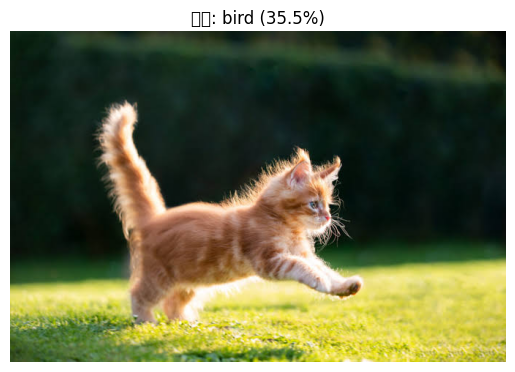

상위 3개 예측:
  bird: 35.5%
  deer: 29.6%
  horse: 22.1%


In [12]:
from PIL import Image
import matplotlib.pyplot as plt

# ↓↓↓ 여기에 구글 드라이브 이미지 경로만 바꿔서 넣으면 됨
img_path = "/content/drive/MyDrive/Lab 01 Image/cat.jpeg"

# 전처리 (학습 때 정규화값과 동일하게, augmentation은 제외)
predict_transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261)),
])

img = Image.open(img_path).convert('RGB')
img_tensor = predict_transform(img).unsqueeze(0).to(device)

model.eval()
with torch.no_grad():
    output = model(img_tensor)
    probs = torch.softmax(output, dim=1)[0]
    pred_idx = probs.argmax().item()

plt.imshow(img)
plt.axis('off')
plt.title(f"예측: {classes[pred_idx]} ({probs[pred_idx]*100:.1f}%)")
plt.show()

top3 = torch.topk(probs, 3)
print("상위 3개 예측:")
for i in range(3):
    print(f"  {classes[top3.indices[i]]}: {top3.values[i]*100:.1f}%")

Everything up-to-date


/content
Cloning into 'undergrad-research-practicum'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (6/6), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 213.98 KiB | 17.83 MiB/s, done.
Resolving deltas: 100% (1/1), done.
/content/undergrad-research-practicum
/content/undergrad-research-practicum
